In [1]:
import spotipy

2026-02-04 12:29:14.935323: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-04 12:29:15.027880: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/package/python-cbrg/current/3.11/lib/python3.11/site-packages/banksy/cluster_methods.py:24: UserWarning: 
No rpy2 installed. BANKSY will run, but mclust will not work.
Note: you can still use the default leiden option for clustering.
Install rpy2 and R in your conda environment if you want to use mclust for clustering.

  warnings.warn(warn_str)


In [2]:
img_df = spotipy.io.load_image_data("Kevin-2018.jpg")
img_df

,row,col,R,G,B
0,0,0,82,82,77
1,0,1,82,82,77
2,0,2,82,82,77
3,0,3,82,82,77
4,0,4,82,82,77
...,...,...,...,...,...
1299595,1139,1135,3,3,8
1299596,1139,1136,5,4,9
1299597,1139,1137,8,7,12
1299598,1139,1138,8,7,12


In [3]:
centroid_df = spotipy.simulate.staggered_grid(
    img_df,
    spacing=15,
)
centroid_df

,x,y
0,0.0,0.000000
1,15.0,0.000000
2,30.0,0.000000
3,45.0,0.000000
4,60.0,0.000000
...,...,...
6683,1072.5,1130.163152
6684,1087.5,1130.163152
6685,1102.5,1130.163152
6686,1117.5,1130.163152


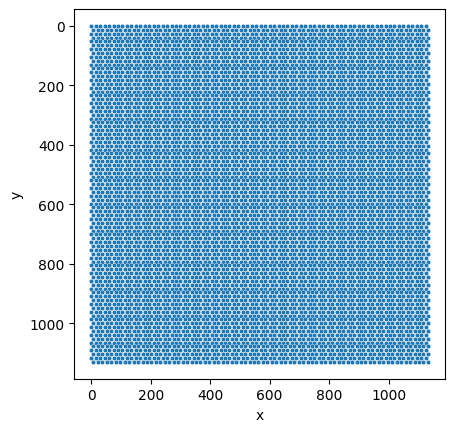

In [4]:
spotipy.plot.xy(centroid_df, size=10)

In [5]:
simulated_data = spotipy.simulate.average_rgb_within_radius(
    centroid_df,
    img_df,
    radius = 5
)
simulated_data

,x,y,R_mean,G_mean,B_mean,n_pixels
0,0.0,0.000000,82.000000,82.000000,77.000000,26
1,15.0,0.000000,82.434783,82.434783,77.869565,46
2,30.0,0.000000,83.000000,83.000000,79.000000,46
3,45.0,0.000000,84.000000,85.000000,80.000000,46
4,60.0,0.000000,84.000000,85.000000,80.000000,46
...,...,...,...,...,...,...
6683,1072.5,1130.163152,7.250000,6.887500,11.600000,80
6684,1087.5,1130.163152,6.950000,8.637500,12.650000,80
6685,1102.5,1130.163152,5.650000,7.237500,11.300000,80
6686,1117.5,1130.163152,6.825000,5.825000,10.825000,80


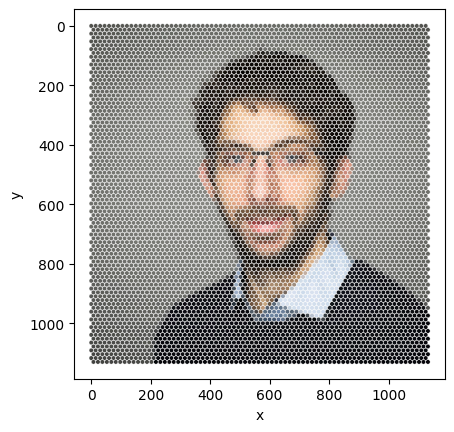

In [6]:
spotipy.plot.rgb(simulated_data, size=10)

In [7]:
results_df = spotipy.cluster.kmeans(simulated_data)
results_df

,x,y,R_mean,G_mean,B_mean,n_pixels,clusters_kmeans
0,0.0,0.000000,82.000000,82.000000,77.000000,26,3
1,15.0,0.000000,82.434783,82.434783,77.869565,46,3
2,30.0,0.000000,83.000000,83.000000,79.000000,46,3
3,45.0,0.000000,84.000000,85.000000,80.000000,46,3
4,60.0,0.000000,84.000000,85.000000,80.000000,46,3
...,...,...,...,...,...,...,...
6683,1072.5,1130.163152,7.250000,6.887500,11.600000,80,1
6684,1087.5,1130.163152,6.950000,8.637500,12.650000,80,1
6685,1102.5,1130.163152,5.650000,7.237500,11.300000,80,1
6686,1117.5,1130.163152,6.825000,5.825000,10.825000,80,1


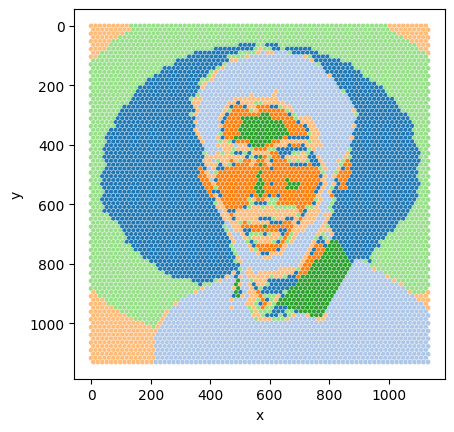

In [8]:
spotipy.plot.cluster(results_df, "clusters_kmeans", size=15)

In [9]:
results_df = spotipy.cluster.banksy(simulated_data, k_geom=10, lambda_list=[0.3], resolution=0.5)
results_df

/package/python-cbrg/current/3.11/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)



Median distance to closest cell = 14.999999999999975

---- Ran median_dist_to_nearest_neighbour in 0.02 s ----

---- Ran generate_spatial_distance_graph in 0.03 s ----

---- Ran row_normalize in 0.03 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 0.21 s ----

---- Ran generate_spatial_distance_graph in 0.04 s ----

---- Ran theta_from_spatial_graph in 0.06 s ----

---- Ran row_normalize in 0.03 s ----

---- Ran generate_spatial_weights_fixed_nbrs in 0.29 s ----

Runtime Feb-04-2026-12-29

3 genes to be analysed:
Gene List:
Index(['R', 'G', 'B'], dtype='object')

Check if X contains only finite (non-NAN) values
Decay Type: scaled_gaussian
Weights Object: {'weights': {0: <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 66880 stored elements and shape (6688, 6688)>, 1: <Compressed Sparse Row sparse matrix of dtype 'complex128'
	with 133760 stored elements and shape (6688, 6688)>}}

Nbr matrix | Mean: 92.72 | Std: 50.48
Size of Nbr | Shape: (6688, 3)
Top 3 entries of

/package/python-cbrg/current/3.11/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


UMAP embedding
------------------------------------------------------------
shape: (6688, 2)


AxisArrays with keys: reduced_pc_9, reduced_pc_9_umap
Decay type: scaled_gaussian
Neighbourhood Contribution (Lambda Parameter): 0.3
reduced_pc_9 

reduced_pc_9_umap 

PCA dims to analyse: [9]

Setting up partitioner for (nbr decay = scaled_gaussian), Neighbourhood contribution = 0.3, PCA dimensions = 9)


Nearest-neighbour weighted graph (dtype: float64, shape: (6688, 6688)) has 133760 nonzero entries.
---- Ran find_nn in 0.30 s ----


Nearest-neighbour connectivity graph (dtype: int16, shape: (6688, 6688)) has 133760 nonzero entries.

(after computing shared NN)
Allowing nearest neighbours only reduced the number of shared NN from 500248 to 133620.


Shared nearest-neighbour (connections only) graph (dtype: int16, shape: (6688, 6688)) has 127490 nonzero entries.

Shared nearest-neighbour (number of shared neighbours as weights) graph (dtype: int16, shape: (6688, 6688)) has 127490 nonzero en

/package/python-cbrg/current/3.11/lib/python3.11/site-packages/banksy/labels.py:398: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  expand_labels(label_list[sort_indices[0]],


,decay,lambda_param,num_pcs,resolution,num_labels,labels,adata,relabeled
scaled_gaussian_pc9_nc0.30_r0.50,scaled_gaussian,0.3,9,0.5,21,"Label object:\nNumber of labels: 21, number of...",[[[View of AnnData object with n_obs × n_vars ...,"Label object:\nNumber of labels: 21, number of..."


/nvme/project/olin0164/spotipy/spotipy/cluster.py:91: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df['clusters_banksy'] = results_df.relabeled[0].dense


,x,y,R_mean,G_mean,B_mean,n_pixels,clusters_kmeans,clusters_banksy
0,0.0,0.000000,82.000000,82.000000,77.000000,26,3,19
1,15.0,0.000000,82.434783,82.434783,77.869565,46,3,19
2,30.0,0.000000,83.000000,83.000000,79.000000,46,3,19
3,45.0,0.000000,84.000000,85.000000,80.000000,46,3,19
4,60.0,0.000000,84.000000,85.000000,80.000000,46,3,19
...,...,...,...,...,...,...,...,...
6683,1072.5,1130.163152,7.250000,6.887500,11.600000,80,1,13
6684,1087.5,1130.163152,6.950000,8.637500,12.650000,80,1,13
6685,1102.5,1130.163152,5.650000,7.237500,11.300000,80,1,13
6686,1117.5,1130.163152,6.825000,5.825000,10.825000,80,1,13


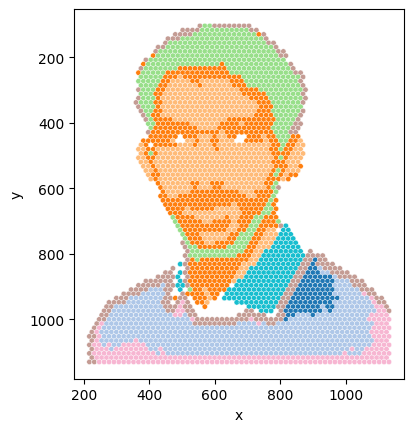

In [11]:
spotipy.plot.cluster(
    results_df,
    "clusters_banksy",
    size=15,
    exclude_labels=[0, 4, 6, 7, 8, 9, 10, 12, 14, 15, 16, 17, 19],
)